<a href="https://colab.research.google.com/github/Luis202403/Simulacion_OSSE_Zapatosa/blob/main/ModelosFVM_Acoplados_Zapatosa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dominio: FORMA REAL (embebida) -> reproduce las figuras del manuscrito
Malla 130x130 | celda 253x273 m | área 499 km²

[MODELO 6] campo solenoidal -> max|div(flujo agua)|=0.0e+00 | masa: error=0.0e+00


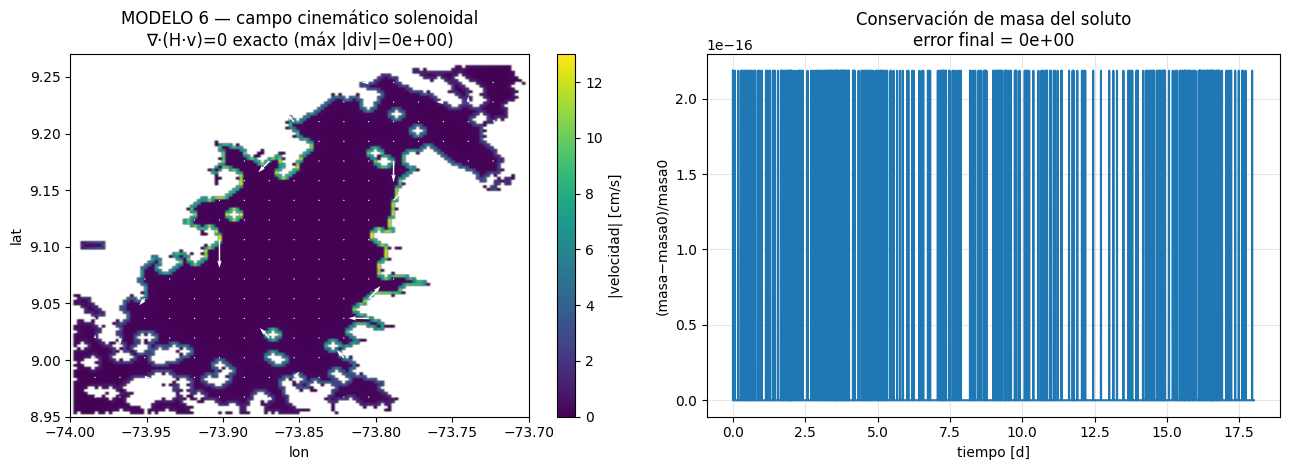

[MODELO 1] pluma de la carga del Cesar (fuente de masa)


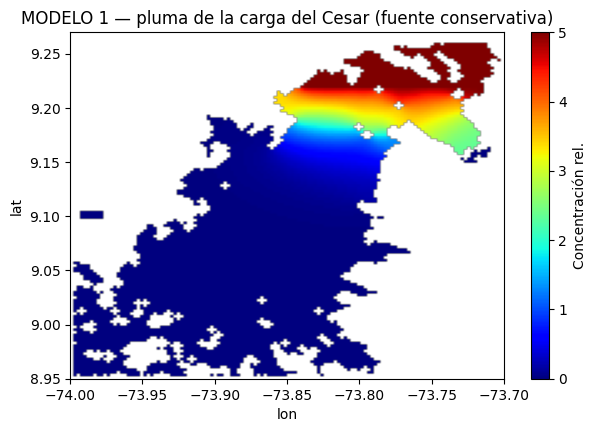

[MODELO 2] decaimiento de primer orden


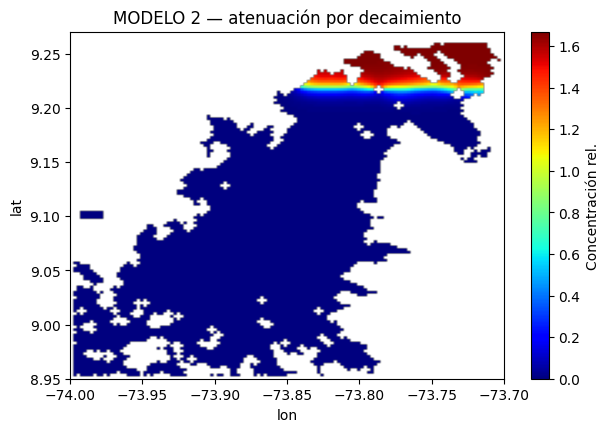

[MODELO 3] pulso de mortandad de macrófitas


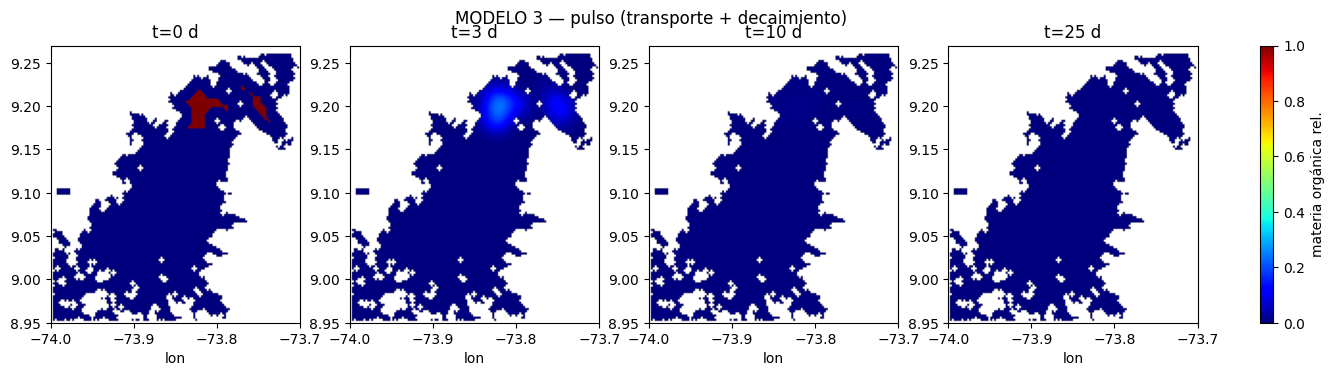


[MODELOS 4+5] acople multiespecie DBO–OD–CH4 (escenario mediano)


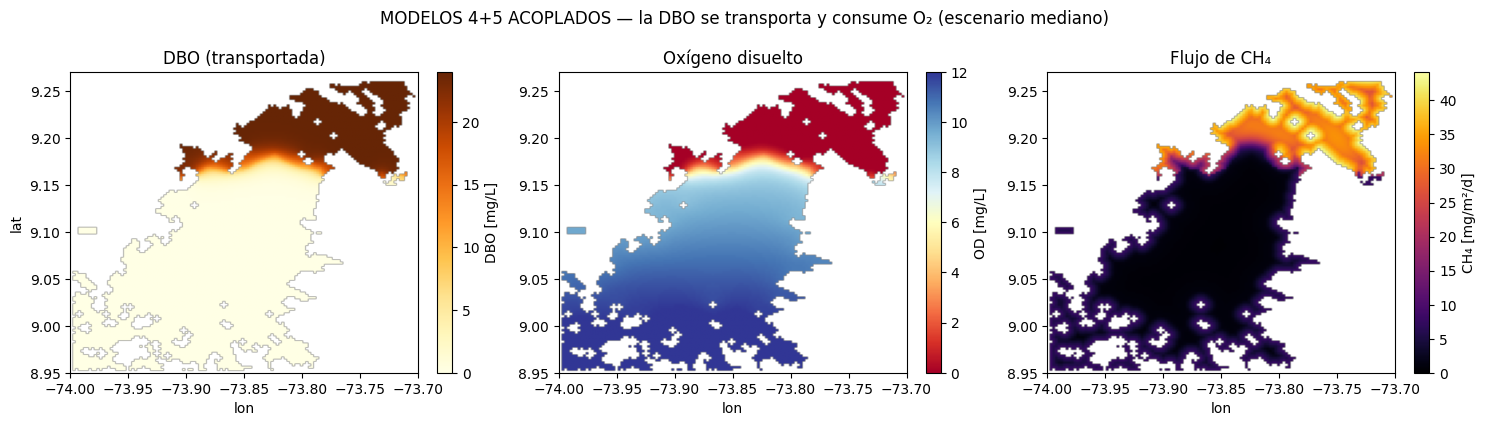


[CADENA ACOPLADA] escenarios de macrófitas
  Bajo    : mantos 5999 ha | OD<4 12% | emisión ~1055 t/año
  Mediano : mantos 11997 ha | OD<4 24% | emisión ~1787 t/año
  Alto    : mantos 20995 ha | OD<4 41% | emisión ~2679 t/año


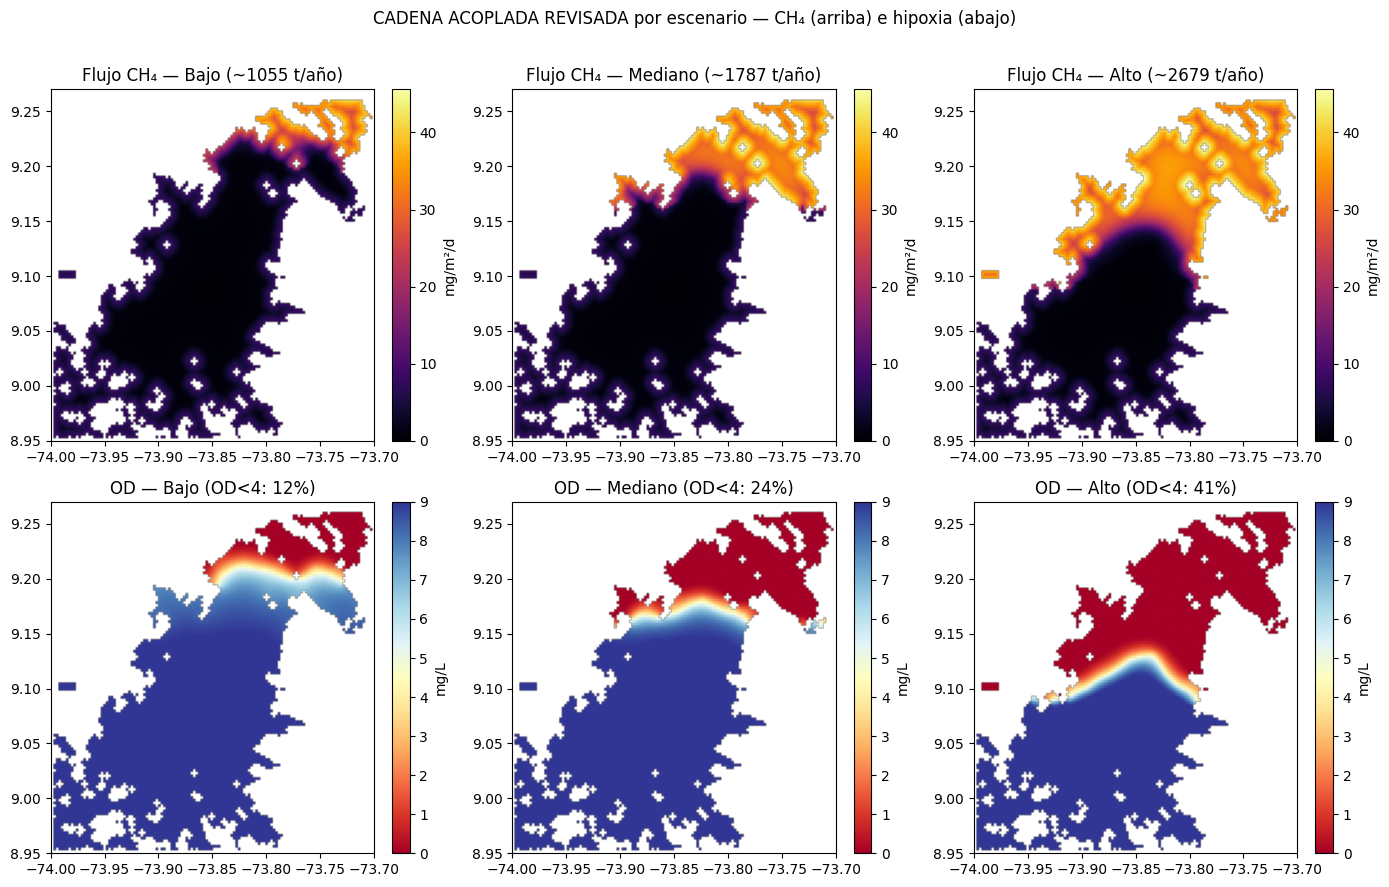


[ENSAMBLE 2D n=1000] malla engrosada (~2-3 min)...
  n=1000: p5=920 mediana=1389 p95=2758


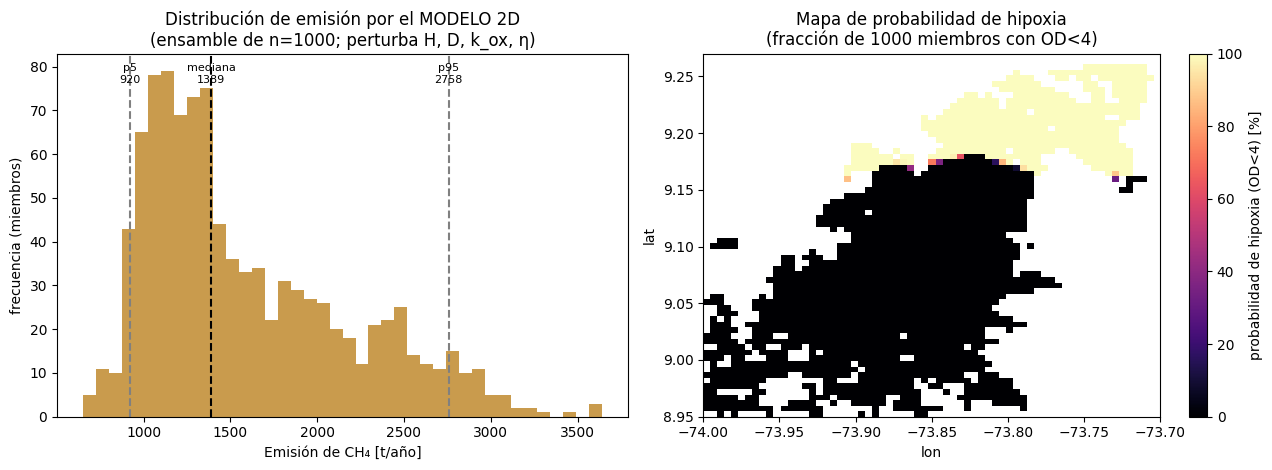


=== FIN: figuras de modelado del manuscrito reproducidas ===


In [1]:
# =====================================================================
#  MODELO INTEGRAL ACOPLADO — CIÉNAGA DE ZAPATOSA  (VERSIÓN REVISADA)
#  Los 6 modelos por VOLÚMENES FINITOS — ejecutable en GOOGLE COLAB
#
#  Reproduce EXACTAMENTE las figuras de modelado del manuscrito:
#    Modelo 6  -> figura de verificación hidrodinámica (campo solenoidal
#                 + conservación de masa)                 [v2_fig_hidro]
#    Modelos 4+5 -> acople multiespecie DBO–OD–CH4        [v2_fig_multiespecie]
#    Cadena    -> CH4 e hipoxia por escenario             [v2_fig_escenarios]
#    Ensamble  -> distribución de emisión + prob. hipoxia [v2_fig_ensamble]
#
#  Correcciones del evaluador ya incorporadas:
#   (A) campo SOLENOIDAL (∇·(H·v)=0 exacto) + régimen de dispersión dominante
#   (B) Modelo 5 MULTIESPECIE: la DBO se transporta y consume O2
#   (C) carga del Cesar como TÉRMINO FUENTE (conservativo)
#   (D) ensamble del MODELO 2D (perturba H, D, k_ox, η) -> UQ espacial
#
#  La forma REAL de la ciénaga va EMBEBIDA: no hay que subir ningún archivo.
#  Estudio PROSPECTIVO/ACADÉMICO: magnitudes indicativas.
# =====================================================================
import numpy as np, matplotlib.pyplot as plt, math, os, zlib, base64
from scipy.ndimage import distance_transform_edt
DAY=86400.; HR=3600.; rng=np.random.default_rng(7)

# ------------------ DOMINIO (forma real embebida) ------------------
_MASK_B64 = ("eNqlVT1vE0EQnfVacSRCTogiFJE3Ej+AMnxEOXfwD6ADlIaOlBaJshdRuHRHhRT4CUg0NPiQkVympInIRSmgiJRLAPmCzzfs9+1ey0qR8m533rx5szsGCNfKx+674trdx1lb4w4efy5hiWELFiQmiBNMaKeE5FEiP3Dcx+TeaQVr8TOJGabxmBUjWGWlIqjy1g7HThqdowwgV124PsRxLpgUQf922lrHqwJiTCVeJSk5RqxuRpgpgjcZbCHicB9zraCETxXHyVesQCtI2psRXuzMNGEkzh0QrIYlT3QJmPEzxGkVgymhHCETlN3EEIh1Kv7Odc2R/PBHfsy0B5H4t5C41AcGWHLkGBsBsP13j4rdAaLGbDdKBMcYsWdMHOQriDNTsVAwfbuIdQK4Mxt/UCqONL5R9iu1f6osgYX5SG3jXCsgFfuGeukDnGYSjGwG9mUuAyZ2nxYqfmYzkioy8eWyJnhoMA6Vy9Fri3UEXXtqsdqHNg0xTRs45wGGIja40HjXKjCm7ZGQgIElKE2CZXtA1UgSwmxAzzTOHjB9cYwmhWO0vsfYyOlwYRoX7oOFszwkKK2CQ1+iEH0StElUHQd8EHVGvmIg40mgELbyMABecc8U2YjIK5GlTvSZKkCGjWoCUrqq8vrR+21xVbkEQA58D8XSd+Xc4QdhjdaVrIFdhijokhQwDQlYEUqMkAeSOqHLri81QcM02sz4skFgNDrJJkXRMEkS5H4KkfGJNonaAKrmIPRsm5Y0yS1uMnZWbN+4kkh+qstDOzjUGbTT5AdeaElGFcMqVgH2hSGKxvwS2PjCp2LiFH05EHVJhXz1m6I0M8dmYo4jT5ghIOVz8cqHl5EtExdF7FRMDeNTnKhWzdxc61kjdYK2e2LOeNJoPcHwtiqfp14jmJ6tYed4TUAbBIbwygWs6/37FsvBKn4/hj6jGO7T3GOYNyTx4H6rRhzG9d2Q8SeD+sEw4Wu2XQfQI2HpBq8vz3uKRTf2XhjB32xSFy2qysRo8HEOuXcbZY/7/NI7ULQ2uBcAe/R77AcsE1F1Cn7K4I0DvIj86yxPjCr47/UPJOWD/Q==")
def construir_dominio():
    ext=np.array([-74.00,-73.70,8.95,9.27])
    try:
        if os.path.exists("real_mask.npy") and os.path.exists("real_extent.npy"):
            print("Dominio: FORMA REAL (archivos subidos)")
            return np.load("real_mask.npy"), np.load("real_extent.npy")
        bits=np.unpackbits(np.frombuffer(zlib.decompress(base64.b64decode(_MASK_B64)),dtype=np.uint8))
        mask=bits[:130*130].reshape(130,130).astype(bool)
        print("Dominio: FORMA REAL (embebida) -> reproduce las figuras del manuscrito")
        return mask, ext
    except Exception as e:
        print("Dominio: IDEALIZADO (fallback):", e)
        ny=nx=130; yy,xx=np.mgrid[0:ny,0:nx].astype(float); X=xx/nx; Y=yy/ny
        mask=((((X-0.45)/0.40)**2+((Y-0.35)/0.28)**2)<1)|((((X-0.62)/0.16)**2+((Y-0.75)/0.26)**2)<1)|((((X-0.55)/0.20)**2+((Y-0.55)/0.30)**2)<1)
        return mask, ext
mask,ext=construir_dominio(); ny,nx=mask.shape; lon0,lon1,lat0,lat1=ext
dx=(lon1-lon0)*111e3*math.cos(math.radians(9.1))/nx; dy=(lat1-lat0)*111e3/ny
cell_ha=dx*dy/1e4; area_km2=mask.sum()*dx*dy/1e6
distn=distance_transform_edt(mask)*((dx+dy)/2); distn/=distn.max()
LON=np.linspace(lon0,lon1,nx); LAT=np.linspace(lat0,lat1,ny); LO,LA=np.meshgrid(LON,LAT)
latn=(LA-lat0)/(lat1-lat0)
def depthfield(Hm=3.5):
    H=0.6+Hm*1.9*distn**1.05; return np.where(mask,H*Hm/np.nanmean(np.where(mask,H,np.nan)),1e-3)
H=depthfield()
print(f"Malla {nx}x{ny} | celda {dx:.0f}x{dy:.0f} m | área {area_km2:.0f} km²")
mEa=mask&np.roll(mask,-1,1);mWa=mask&np.roll(mask,1,1);mNa=mask&np.roll(mask,-1,0);mSa=mask&np.roll(mask,1,0)

# --------- NÚCLEO FV CONSERVATIVO (masa = ∫ C·H·dA), flujos en caras ----------
def transport(C,D,H,q):
    qE,qW,qN,qS=q
    CE=np.where(qE>=0,C,np.roll(C,-1,1));CW=np.where(qW>=0,np.roll(C,1,1),C)
    CN=np.where(qN>=0,C,np.roll(C,-1,0));CS=np.where(qS>=0,np.roll(C,1,0),C)
    net=(qE*CE-qW*CW)+(qN*CN-qS*CS)
    HE=0.5*(H+np.roll(H,-1,1));HW=0.5*(H+np.roll(H,1,1));HN=0.5*(H+np.roll(H,-1,0));HS=0.5*(H+np.roll(H,1,0))
    dif=D*dy/dx*(np.where(mEa,HE*(np.roll(C,-1,1)-C),0)-np.where(mWa,HW*(C-np.roll(C,1,1)),0)) \
       +D*dx/dy*(np.where(mNa,HN*(np.roll(C,-1,0)-C),0)-np.where(mSa,HS*(C-np.roll(C,1,0)),0))
    return (-net+dif)/(H*dx*dy)
def dt_estable(D,q,kmax=0.0):
    um=max(np.nanmax(np.hypot(0.5*(q[0]+q[1])/(dy*H),0.5*(q[2]+q[3])/(dx*H))[mask]),1e-9)
    return 0.25*min(dx/um,dx*dx/(4*D),(1.0/kmax if kmax>0 else 1e9))
def mapa(c,t,cmap='jet',vmin=0,vmax=None,cb=''):
    plt.figure(figsize=(7,4.5)); im=plt.imshow(np.where(mask,c,np.nan),origin='lower',extent=ext,cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    plt.colorbar(im,label=cb); plt.title(t); plt.xlabel('lon'); plt.ylabel('lat'); plt.show()

# =====================================================================
# =====================  MODELO 6  ====================================
#  CAMPO DE VELOCIDAD SOLENOIDAL (función de corriente en esquinas).
#  Flujos de volumen en caras = diferencias de psi -> divergencia del
#  flujo de agua EXACTAMENTE cero. (Corrige crítica A.)
#  FIGURA: campo solenoidal + conservación de masa  [= v2_fig_hidro]
# =====================================================================
def solenoidal(A=50.0):
    Yc,Xc=np.mgrid[0:ny+1,0:nx+1].astype(float); Xc/=nx; Yc/=ny
    inner=np.zeros((ny+1,nx+1),bool); inner[1:-1,1:-1]=mask[1:,1:]&mask[:-1,1:]&mask[1:,:-1]&mask[:-1,:-1]
    psi=np.where(inner,A*np.sin(np.pi*Xc)*np.sin(np.pi*Yc),0.0)
    Fx=psi[1:,:]-psi[:-1,:]; Fy=psi[:,:-1]-psi[:,1:]
    return Fx[:,1:],Fx[:,:-1],Fy[1:,:],Fy[:-1,:]
qE,qW,qN,qS=solenoidal(50.0); divW=(qE-qW)+(qN-qS)
ue=0.5*(qE+qW)/(dy*H); ve=0.5*(qN+qS)/(dx*H)
# prueba de conservación de masa con el campo solenoidal (dominio cerrado, sin fuente)
_r=np.random.default_rng(0); C=np.where(mask,1.0+0.5*_r.random((ny,nx)),0.0)
masa=lambda C: np.nansum((C*H)[mask])*dx*dy; m0=masa(C); serie=[]
umax=max(np.nanmax(np.hypot(ue,ve)[mask]),1e-9); _dt=0.2*min(dx/umax,dx*dx/(4*2.0))
for _ in range(4000):
    C=C+_dt*transport(C,2.0,H,(qE,qW,qN,qS)); C=np.where(mask,C,0.0); serie.append((masa(C)-m0)/m0)
print(f"\n[MODELO 6] campo solenoidal -> max|div(flujo agua)|={np.abs(divW[mask]).max():.1e} | masa: error={abs(serie[-1]):.1e}")
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
im=ax[0].imshow(np.where(mask,np.hypot(ue,ve)*100,np.nan),origin='lower',extent=ext,cmap='viridis',aspect='auto')
plt.colorbar(im,ax=ax[0],label='|velocidad| [cm/s]'); s=7
ax[0].quiver(LO[::s,::s],LA[::s,::s],ue[::s,::s],ve[::s,::s],color='white',scale=2.0)
ax[0].set_title(f'MODELO 6 — campo cinemático solenoidal\n∇·(H·v)=0 exacto (máx |div|={np.abs(divW[mask]).max():.0e})')
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat')
ax[1].plot(np.arange(len(serie))*_dt/86400, serie); ax[1].ticklabel_format(axis='y',style='sci',scilimits=(0,0)); ax[1].grid(alpha=.3)
ax[1].set_xlabel('tiempo [d]'); ax[1].set_ylabel('(masa−masa0)/masa0'); ax[1].set_title(f'Conservación de masa del soluto\nerror final = {abs(serie[-1]):.0e}')
plt.tight_layout(); plt.show()
# Por defecto, los modelos siguientes usan DISPERSIÓN DOMINANTE (u=v=0):
q0=(np.zeros_like(mask,float),)*4

# =====================================================================
# =====================  MODELO 1  ====================================
#  ADVECCIÓN–DIFUSIÓN, carga del Cesar como TÉRMINO FUENTE de masa
#  (conservativo, sin sobreescritura). (Corrige crítica C.)
# =====================================================================
print("[MODELO 1] pluma de la carga del Cesar (fuente de masa)")
D=2.0; entrada=mask&(latn>np.nanpercentile(np.where(mask,latn,np.nan),92))
Sload=np.where(entrada, 1.0/DAY, 0.0)
C1=np.zeros_like(H); dt=dt_estable(D,q0)
for _ in range(4000):
    C1=C1+dt*(transport(C1,D,H,q0)+Sload); C1=np.where(mask,np.clip(C1,0,5),0.)
mapa(C1,'MODELO 1 — pluma de la carga del Cesar (fuente conservativa)',cmap='jet',cb='Concentración rel.')

# =====================================================================
# =====================  MODELO 2  ====================================
#  DECAIMIENTO DE PRIMER ORDEN (atenuación N–S, tipo Streeter–Phelps)
# =====================================================================
print("[MODELO 2] decaimiento de primer orden")
k2=0.6/DAY; C2=np.zeros_like(H); dt=dt_estable(D,q0,kmax=k2)
for _ in range(4000):
    C2=C2+dt*(transport(C2,D,H,q0)+Sload-k2*C2); C2=np.where(mask,np.clip(C2,0,5),0.)
mapa(C2,'MODELO 2 — atenuación por decaimiento',cmap='jet',cb='Concentración rel.')

# =====================================================================
# =====================  MODELO 3  ====================================
#  PULSO INSTANTÁNEO (mortandad de macrófitas: condición inicial)
# =====================================================================
print("[MODELO 3] pulso de mortandad de macrófitas")
C3=np.zeros_like(H); C3[mask&(latn>0.70)&(distn>0.25)]=1.0; k3=0.4/DAY
dt=dt_estable(D,q0,kmax=k3); snaps={0:C3.copy()}; obj=[3*DAY,10*DAY,25*DAY]; t=0.;i=0
while i<len(obj):
    C3=C3+dt*(transport(C3,D,H,q0)-k3*C3); C3=np.where(mask,np.clip(C3,0,1),0.); t+=dt
    if t>=obj[i]: snaps[obj[i]]=C3.copy(); i+=1
fig,ax=plt.subplots(1,4,figsize=(16,3.6))
for a,tp in zip(ax,sorted(snaps)):
    im=a.imshow(np.where(mask,snaps[tp],np.nan),origin='lower',extent=ext,cmap='jet',vmin=0,vmax=1,aspect='auto')
    a.set_title(f't={tp/DAY:.0f} d'); a.set_xlabel('lon')
fig.colorbar(im,ax=ax,fraction=0.025,label='materia orgánica rel.'); plt.suptitle('MODELO 3 — pulso (transporte + decaimiento)'); plt.show()

# =====================================================================
# ================  MODELOS 4 + 5  ACOPLADOS  =========================
#  MULTIESPECIE DINÁMICO: DBO (L) + OD (O) + CH4 (M) a la vez. La DBO
#  se TRANSPORTA y consume O2 (-Kd·L en la ec. de oxígeno). El CH4 tiene
#  transferencia bifásica (Henry + ebullición). (Corrige crítica B.)
#  FIGURA = v2_fig_multiespecie
# =====================================================================
def correr_acoplado(area_ha,H=None,D=2.0,kox=0.1/HR,q=None,Tdays=30,Kd=0.25/DAY,Smac_areal=None):
    if H is None: H=depthfield()
    if q is None: q=q0
    ka,Os,SOD,kL,KO2=0.8/DAY,7.0,0.6/DAY,0.7/DAY,1.0
    score=np.where(mask,0.82*latn+0.18*(1-distn),-1.); order=np.argsort(score[mask])[::-1]; wi=np.where(mask)
    n=int(min(mask.sum(),area_ha/cell_ha)); sel=order[:n]; mat=np.zeros_like(mask); mat[(wi[0][sel],wi[1][sel])]=True
    ebf=np.clip(1-H/3.0,0,0.85)
    Smac=(1250*0.6*0.77*0.165*0.66)*0.12/(365*DAY) if Smac_areal is None else Smac_areal
    SL=np.where(mat,6.0/DAY,0.); Sm=np.where(mat,Smac,0.)+np.where(mask,12.0/1000/DAY,0.)
    prod=np.where(mask&~mat,(1-latn)**1.2*5.5/DAY,0.)
    L=np.zeros_like(H); O=np.where(mask,7.,0.); M=np.where(mask,0.02,0.); dt=dt_estable(D,q,kmax=max(kox,ka+Kd))
    for _ in range(int(Tdays*DAY/dt)):
        L=L+dt*(transport(L,D,H,q)-Kd*L+SL)
        O=O+dt*(transport(O,D,H,q)+ka*(Os-O)-Kd*L-SOD/H+prod)     # O2 consumido por la DBO transportada
        M=M+dt*(transport(M,D,H,q)+Sm*(1-ebf)/H-kox*(O/(KO2+O))*M-kL/H*M)
        L=np.where(mask,np.clip(L,0,50),0.);O=np.where(mask,np.clip(O,0,14),0.);M=np.where(mask,np.clip(M,0,5),0.)
    flujo=(kL*M+ebf*Sm)*DAY*1000
    return dict(L=np.where(mask,L,np.nan),O=np.where(mask,O,np.nan),flujo=np.where(mask,flujo,np.nan),
                emis=np.nansum(flujo[mask])*cell_ha*1e4/1e6, hyp=(O[mask]<4).mean()*100, mat=mat.sum()*cell_ha)
print("\n[MODELOS 4+5] acople multiespecie DBO–OD–CH4 (escenario mediano)")
r=correr_acoplado(12000.,Tdays=30)
fig,ax=plt.subplots(1,3,figsize=(15,4.3))
for a,c,t,cm,vm,lb in [(ax[0],r['L'],'DBO (transportada)','YlOrBr',None,'DBO [mg/L]'),
                       (ax[1],r['O'],'Oxígeno disuelto','RdYlBu',12,'OD [mg/L]'),
                       (ax[2],r['flujo'],'Flujo de CH₄','inferno',None,'CH₄ [mg/m²/d]')]:
    im=a.imshow(c,origin='lower',extent=ext,cmap=cm,vmin=0,vmax=vm,aspect='auto'); plt.colorbar(im,ax=a,fraction=0.05,label=lb); a.set_title(t); a.set_xlabel('lon')
ax[0].set_ylabel('lat'); plt.suptitle('MODELOS 4+5 ACOPLADOS — la DBO se transporta y consume O₂ (escenario mediano)'); plt.tight_layout(); plt.show()

# --------- CADENA POR ESCENARIOS  (= v2_fig_escenarios) ----------
print("\n[CADENA ACOPLADA] escenarios de macrófitas")
res={}
for nm,a in [('Bajo',6000.),('Mediano',12000.),('Alto',21000.)]:
    res[nm]=correr_acoplado(a,Tdays=30)
    print(f"  {nm:8s}: mantos {res[nm]['mat']:.0f} ha | OD<4 {res[nm]['hyp']:.0f}% | emisión ~{res[nm]['emis']*365/1000:.0f} t/año")
fig,ax=plt.subplots(2,3,figsize=(14,9)); fmax=max(np.nanmax(res[k]['flujo']) for k in res)
for j,nm in enumerate(res):
    im=ax[0,j].imshow(res[nm]['flujo'],origin='lower',extent=ext,cmap='inferno',vmin=0,vmax=fmax,aspect='auto')
    ax[0,j].set_title(f"Flujo CH₄ — {nm} (~{res[nm]['emis']*365/1000:.0f} t/año)"); plt.colorbar(im,ax=ax[0,j],fraction=0.05,label='mg/m²/d')
    im2=ax[1,j].imshow(res[nm]['O'],origin='lower',extent=ext,cmap='RdYlBu',vmin=0,vmax=9,aspect='auto')
    ax[1,j].set_title(f"OD — {nm} (OD<4: {res[nm]['hyp']:.0f}%)"); plt.colorbar(im2,ax=ax[1,j],fraction=0.05,label='mg/L')
plt.suptitle('CADENA ACOPLADA REVISADA por escenario — CH₄ (arriba) e hipoxia (abajo)')
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

# =====================================================================
#  ENSAMBLE 2D (n=1000): conecta la incertidumbre al FVM (crítica D)
#  Cada miembro es una simulación 2D completa; por costo se corre en una
#  MALLA ENGROSADA (x2) para que n=1000 sea tratable (~2-3 min). El rango
#  de emisión de REFERENCIA es el Monte Carlo escalar (N=40.000); aquí el
#  producto clave es el MAPA DE PROBABILIDAD DE HIPOXIA.  (= v2_fig_ensamble)
# =====================================================================
print("\n[ENSAMBLE 2D n=1000] malla engrosada (~2-3 min)...")
mc=(mask[:ny//2*2,:nx//2*2].reshape(ny//2,2,nx//2,2).mean((1,3))>=0.5)
nyc,nxc=mc.shape; dxc=dx*nx/nxc; dyc=dy*ny/nyc; cell_hac=dxc*dyc/1e4
dnc=distance_transform_edt(mc)*((dxc+dyc)/2); dnc/=dnc.max()
LATc=np.linspace(lat0,lat1,nyc); LONc=np.linspace(lon0,lon1,nxc); _,LAc=np.meshgrid(LONc,LATc); latnc=(LAc-lat0)/(lat1-lat0)
mEc=mc&np.roll(mc,-1,1);mWc=mc&np.roll(mc,1,1);mNc=mc&np.roll(mc,-1,0);mSc=mc&np.roll(mc,1,0)
def Hc(Hm): H=0.6+Hm*1.9*dnc**1.05; return np.where(mc,H*Hm/np.nanmean(np.where(mc,H,np.nan)),1e-3)
sc=np.where(mc,0.82*latnc+0.18*(1-dnc),-1.); oc=np.argsort(sc[mc])[::-1]; wic=np.where(mc)
ncm=int(min(mc.sum(),12000./cell_hac)); selc=oc[:ncm]; matc=np.zeros_like(mc); matc[(wic[0][selc],wic[1][selc])]=True
prodc=np.where(mc&~matc,(1-latnc)**1.2*5.5/DAY,0.); SLc=np.where(matc,6.0/DAY,0.)
def difc(C,D,H):
    HE=0.5*(H+np.roll(H,-1,1));HW=0.5*(H+np.roll(H,1,1));HN=0.5*(H+np.roll(H,-1,0));HS=0.5*(H+np.roll(H,1,0))
    return (D*dyc/dxc*(np.where(mEc,HE*(np.roll(C,-1,1)-C),0)-np.where(mWc,HW*(C-np.roll(C,1,1)),0)) \
           +D*dxc/dyc*(np.where(mNc,HN*(np.roll(C,-1,0)-C),0)-np.where(mSc,HS*(C-np.roll(C,1,0)),0)))/(H*dxc*dyc)
def miembro(Hm,Dp,koxp,Kd,eta,Td=18):
    H=Hc(Hm); ka,Os,SOD,kL,KO2=0.8/DAY,7.0,0.6/DAY,0.7/DAY,1.0
    ebf=np.clip(1-H/3.0,0,0.85); Sm=np.where(matc,(1250*0.6*0.77*0.165*0.66)*eta/(365*DAY),0.)+np.where(mc,12.0/1000/DAY,0.)
    L=np.zeros_like(H);O=np.where(mc,7.,0.);M=np.where(mc,0.02,0.); dt=0.25*min(dxc*dxc/(4*Dp),1.0/max(koxp,ka+Kd))
    for _ in range(int(Td*DAY/dt)):
        L=L+dt*(difc(L,Dp,H)-Kd*L+SLc); O=O+dt*(difc(O,Dp,H)+ka*(Os-O)-Kd*L-SOD/H+prodc)
        M=M+dt*(difc(M,Dp,H)+Sm*(1-ebf)/H-koxp*(O/(KO2+O))*M-kL/H*M)
        L=np.where(mc,np.clip(L,0,50),0);O=np.where(mc,np.clip(O,0,14),0);M=np.where(mc,np.clip(M,0,5),0)
    return np.nansum(((kL*M+ebf*Sm)*DAY*1000)[mc])*cell_hac*1e4/1e6*365/1000., O
rg=np.random.default_rng(3); em=[]; hpc=np.zeros_like(mc,float)
for k in range(1000):
    eta=np.exp(rg.uniform(np.log(0.02),np.log(0.30)));Kd=rg.uniform(0.15,0.35)/DAY
    Hm=rg.uniform(3.0,4.2);Dp=rg.uniform(1.0,4.0);koxp=rg.uniform(0.05,0.2)/HR
    e,O=miembro(Hm,Dp,koxp,Kd,eta); em.append(e); hpc+=(np.nan_to_num(O,nan=99)<4)
em=np.array(em); hpc=np.where(mc,hpc/1000*100,np.nan)
p5,p50,p95=np.percentile(em,[5,50,95]); print(f"  n=1000: p5={p5:.0f} mediana={p50:.0f} p95={p95:.0f}")
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
ax[0].hist(em,bins=40,color='#C08A2E',alpha=.85)
for v,l,c in [(p5,'p5','gray'),(p50,'mediana','k'),(p95,'p95','gray')]: ax[0].axvline(v,ls='--',color=c); ax[0].text(v,ax[0].get_ylim()[1]*.92,f'{l}\n{v:.0f}',ha='center',fontsize=8)
ax[0].set_xlabel('Emisión de CH₄ [t/año]'); ax[0].set_ylabel('frecuencia (miembros)'); ax[0].set_title('Distribución de emisión por el MODELO 2D\n(ensamble de n=1000; perturba H, D, k_ox, η)')
im=ax[1].imshow(hpc,origin='lower',extent=ext,cmap='magma',vmin=0,vmax=100,aspect='auto'); plt.colorbar(im,ax=ax[1],label='probabilidad de hipoxia (OD<4) [%]')
ax[1].set_title('Mapa de probabilidad de hipoxia\n(fracción de 1000 miembros con OD<4)'); ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat')
plt.tight_layout(); plt.show()
print("\n=== FIN: figuras de modelado del manuscrito reproducidas ===")